In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("./CSVs/placement_test.csv")

In [6]:
df_col=df.columns

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='cgpa'>

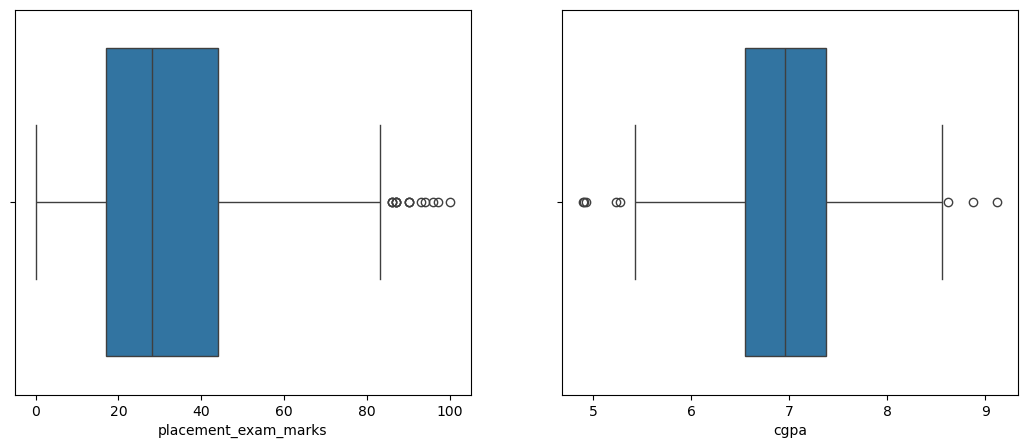

In [25]:
plt.figure(figsize=(20,5))
plt.subplot(1,3,1)
sns.boxplot(x=df.placement_exam_marks)

plt.subplot(1,3,2)
sns.boxplot(x=df.cgpa)


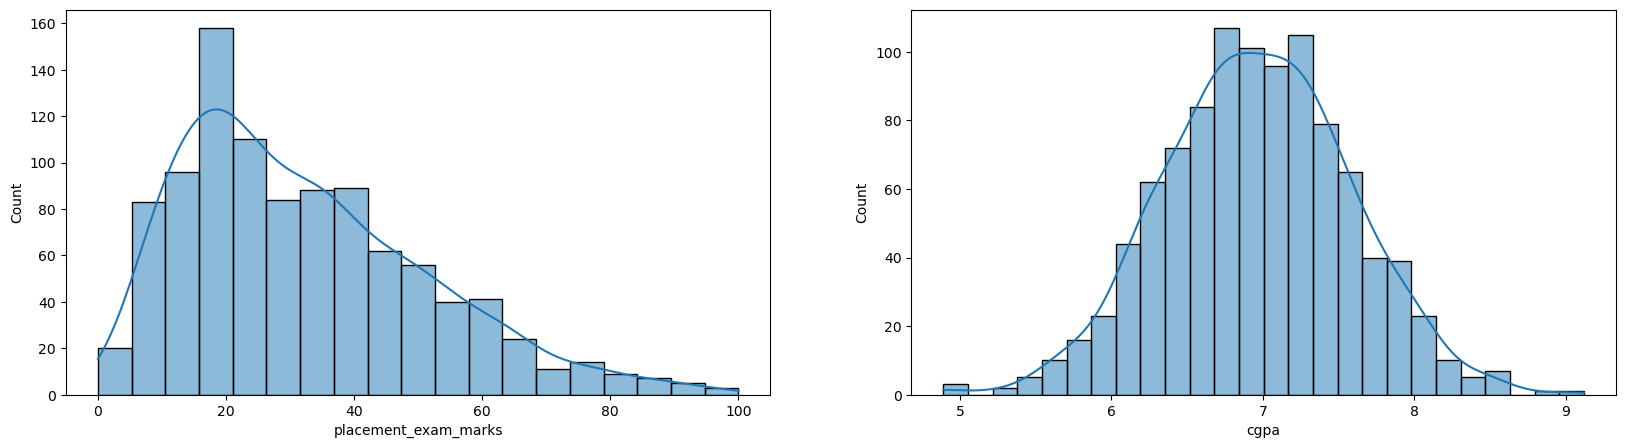

In [38]:
fig , axes = plt.subplots(1,2,figsize=(20,5))

sns.histplot(x=df.placement_exam_marks,ax=axes[0],kde=True)

sns.histplot(x=df.cgpa,ax=axes[1],kde=True)
plt.show()

In [40]:
df.placement_exam_marks.quantile(0.25)

np.float64(17.0)

In [42]:
df.placement_exam_marks.quantile(0.75)

np.float64(44.0)

In [52]:
upper_limit=df.placement_exam_marks.quantile(0.75)
lower_limit=df.placement_exam_marks.quantile(0.25)
iqr=upper_limit-lower_limit


upper_limit=upper_limit+(1.5*iqr)
lower_limit=lower_limit-(1.5*iqr)


In [58]:
print(upper_limit,lower_limit)

84.5 -23.5


In [56]:
df[(df['placement_exam_marks']>upper_limit) | (df['placement_exam_marks']<lower_limit)]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


# Trimming

In [61]:
new_df=df[(df['placement_exam_marks']<upper_limit) & (df['placement_exam_marks']>lower_limit)]

<Axes: xlabel='placement_exam_marks'>

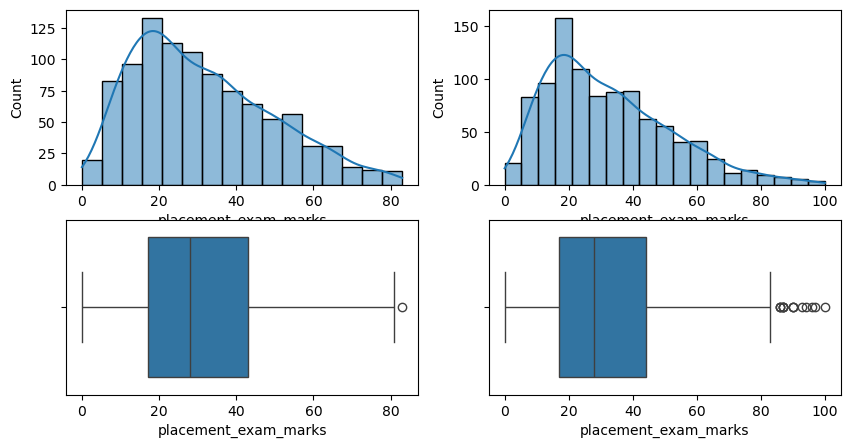

In [72]:
fig,ax=plt.subplots(2,2,figsize=(10,5))
sns.histplot(new_df.placement_exam_marks, kde=True, ax=ax[0, 0])
sns.histplot(df.placement_exam_marks, kde=True, ax=ax[0, 1])

# Row 1: Boxplots
sns.boxplot(x=new_df.placement_exam_marks, ax=ax[1, 0])
sns.boxplot(x=df.placement_exam_marks, ax=ax[1, 1])

# Capping

In [75]:
new_1=np.where(df.placement_exam_marks<lower_limit,
         lower_limit,
         np.where(df.placement_exam_marks>upper_limit,
                  upper_limit,
                  df.placement_exam_marks
                 )
        )

<Axes: >

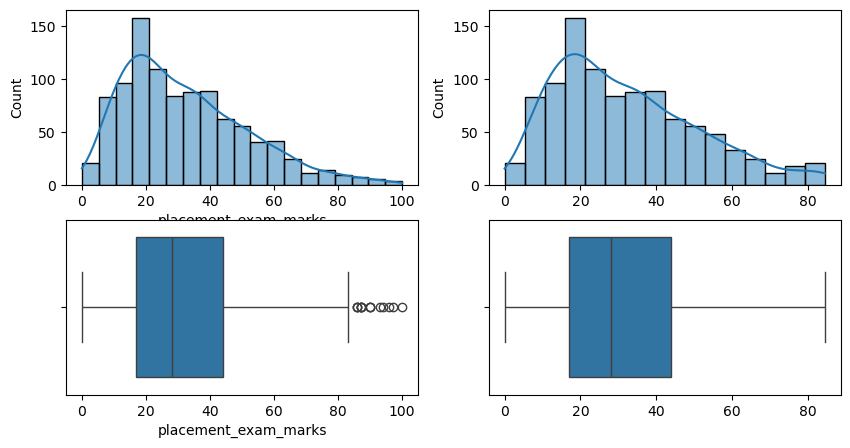

In [79]:
fig,ax=plt.subplots(2,2,figsize=(10,5))
sns.histplot(df.placement_exam_marks, kde=True, ax=ax[0, 0])
sns.histplot(new_1, kde=True, ax=ax[0, 1])


# Row 1: Boxplots
sns.boxplot(x=df.placement_exam_marks, ax=ax[1, 0])
sns.boxplot(x=new_1, ax=ax[1, 1])